# Load and clean the raw EEG data of auditory experiment

## Configuration

All researcher- and setup-specific choices for this pipeline (file paths, which channels are EEG/EOG/reference, the EEG system, power-line frequency, filter bands, ICA settings, event codes, epoch windows, ...) live in **`config.json`** at the repository root, instead of being hardcoded throughout the notebook. This is the file you should edit when adapting this tutorial to your own recording — you should rarely need to change the code cells themselves.

Open `config.json` next to this notebook to see every adjustable parameter and a short note on what it controls.

In [1]:
import json
import numpy as np
import mne
from mne_icalabel import label_components
from pathlib import Path

# Load researcher/setup-specific settings. Edit config.json, not this cell, to adapt this tutorial to your own data.
try:
    with open('config.json') as f:
        config = json.load(f)
except json.JSONDecodeError as e:
    raise ValueError(
        f"config.json has invalid JSON syntax: {e}\n"
        "Common causes: a trailing comma after the last item in a list/object, "
        "single quotes instead of double quotes, or Python's None/True/False "
        "instead of JSON's null/true/false. Open config.json in a text editor "
        "and check the line/column mentioned above."
    ) from e

# Folder where the data is stored
data_folder = Path(config['paths']['data_folder'])

# Folder where the cleaned data will be stored
cleaned_data_folder = Path(config['paths']['cleaned_data_folder'])
cleaned_data_folder.mkdir(exist_ok=True)  # create the folder if it doesn't exist

# Folder where figures will be saved
figures_folder = Path(config['paths']['figures_folder'])
figures_folder.mkdir(exist_ok=True)

# Participant's filename
participant_filename = config['paths']['raw_filename']

# Filename without extension, used as a prefix for every file this notebook writes
participant_stem = participant_filename.replace('.bdf', '')

## Logging and saved figures

Alongside the config file, this notebook writes a plain-text log (via Python's `logging` module) to `config['paths']['logs_folder']`. This is separate from the notebook's own cell output: a log file gives you a permanent, greppable record of exactly what happened on a given run — which channels were excluded, how many events were found, which ICA components were removed, ... — which matters for provenance, and becomes essential once you're not watching the notebook run interactively (e.g. running it non-interactively via `jupyter nbconvert --execute` across many participants).

The log file is opened in **append** mode, so re-running the notebook adds to the existing log rather than overwriting it. Each run starts with a timestamped `=== Starting ... ===` line, so you can always tell where one run ends and the next begins.

The cell below also defines a small `save_fig()` helper. Every figure worth keeping is written to `config['paths']['figures_folder']` as a PNG named after the participant, so the QC plots survive after the notebook is closed. Two details it handles for you:
- Some MNE functions (`plot_components` with many components, `plot_properties`) return a **list** of figures rather than one; each gets its own numbered file.
- **Interactive browsers cannot be saved.** `raw.plot()`, `epochs.plot()`, and `ica.plot_sources()` return live Qt browser windows, not matplotlib figures — they have no `savefig`. Those are for on-screen inspection only; the `mne.Report` at the end of the notebook covers the raw data separately.

In [2]:
import logging

logs_folder = Path(config['paths']['logs_folder'])
logs_folder.mkdir(exist_ok=True)

logger = logging.getLogger(f"neuropipe.clean.{participant_filename}")
logger.setLevel(logging.INFO)
if logger.hasHandlers():
    logger.handlers.clear()  # avoid duplicate handlers if this cell is re-run

log_path = logs_folder / f"{participant_stem}_cleaning.log"
file_handler = logging.FileHandler(log_path, mode='a')  # append, so earlier runs are never overwritten
file_handler.setFormatter(logging.Formatter('%(asctime)s - %(levelname)s - %(message)s'))
logger.addHandler(file_handler)

console_handler = logging.StreamHandler()
console_handler.setFormatter(logging.Formatter('%(levelname)s - %(message)s'))
logger.addHandler(console_handler)

logger.info(f"=== Starting cleaning pipeline for {participant_filename} ===")


def save_fig(fig, name, dpi=300):
    """Save a figure into the figures folder, prefixed with the participant name.

    Some MNE plotting functions return a *list* of figures rather than one
    (e.g. plot_components pages its output when there are many components, and
    plot_properties returns one figure per component), so both cases are handled.
    Interactive browsers such as raw.plot() cannot be saved this way - under the Qt
    backend they are live browser windows, not matplotlib figures.
    """
    figs = fig if isinstance(fig, (list, tuple)) else [fig]
    paths = []
    for i, f in enumerate(figs):
        suffix = f"_{i + 1}" if len(figs) > 1 else ""
        path = figures_folder / f"{participant_stem}_{name}{suffix}.png"
        f.savefig(path, dpi=dpi, bbox_inches='tight')
        paths.append(path)
    logger.info(f"Saved figure '{name}' to {', '.join(str(p) for p in paths)}")
    return paths

INFO - === Starting cleaning pipeline for p34.bdf ===


## (a) Reading EEG files using MNE-Python

### Read your raw file

This notebook is written for **BioSemi** recordings, which are stored as `.bdf` files and read with `mne.io.read_raw_bdf`. MNE provides readers for many other EEG formats too, which you can explore in the [MNE documentation](https://mne.tools/stable/api/reading_raw_data.html).

EEG files can easily be several GB, depending on sampling rate, duration, and channel count — the cell below prints the actual size of your file. Above a couple of GB, `preload=False` is set (as done here) to load the data in chunks instead of all at once; for smaller files, `preload=True` is simpler and loads everything into memory immediately. Additionally, the channels listed in `config['channels']['exclude']` are excluded because they were unused during recording (here, `EXG5`–`EXG8`). While these channels are present in the data, they contain no meaningful information — check your own system's channel list and update this entry in `config.json` accordingly.

After loading the file, `raw.info` is printed. Key details include:
- **Sampling frequency**: 16.384 kHz (set high for subcortical analyses, but not required for this tutorial).
- **Filters**: Frequencies in raw data range from 0 to 3334 Hz.
- **Channels**: 36 total:
  - 32 are EEG channels.
  - 4 are external channels (Electrooculogram (EOG) and mastoids).
  - 1 additional channel is labeled as Stimulus.

Note: the external channels will be re-labeled and the appropriate montage assigned in the next step to ensure accurate channel definitions.

Always have aproper look at the `raw.info` to ensure everything is correct.

In [3]:
# Print the actual size of the file we're about to read (see markdown above)
file_size_gb = (data_folder / participant_filename).stat().st_size / 1e9
print(f"File size: {file_size_gb:.2f} GB")

# Read raw data
raw = mne.io.read_raw_bdf(
    data_folder / participant_filename, 
    preload=False,
    exclude=config['channels']['exclude'],
)

# Print duration of the recording
print(f"Duration of the recording: {raw.times[-1]:.2f} seconds")
logger.info(f"Loaded {participant_filename} ({file_size_gb:.2f} GB): {raw.times[-1]:.2f} s, {len(raw.ch_names)} channels")

File size: 7.94 GB
Extracting BDF parameters from data/p34.bdf...
Setting channel info structure...
Creating raw.info structure...


INFO - Loaded p34.bdf (7.94 GB): 3939.00 s, 37 channels


Duration of the recording: 3939.00 seconds


In [4]:
# Check info about the raw data
raw.info

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, AF3, F7, F3, FC1, FC5, T7, C3, CP1, CP5, P7, P3, Pz, PO3, ...
 chs: 36 EEG, 1 Stimulus
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 3334.0 Hz
 meas_date: 2023-02-15 15:29:08 UTC
 nchan: 37
 projs: []
 sfreq: 16384.0 Hz
 subject_info: <subject_info | his_id: >
>

In [5]:
# Set the EOG channels named in config.json
raw.set_channel_types(dict.fromkeys(config['channels']['eog'], 'eog'))

# Set the reference channels named in config.json---these do not directly exist as a channel type, so they are set as 'misc' (miscellaneous)
raw.set_channel_types(dict.fromkeys(config['channels']['reference'], 'misc'))

# Now that we have the EEG channels properly set according to the cap used, set the montage named in config.json
montage = mne.channels.make_standard_montage(config['channels']['montage'])
raw.set_montage(montage)

logger.info(f"Set channel types (eog={config['channels']['eog']}, reference={config['channels']['reference']}) and montage '{config['channels']['montage']}'")

# Check raw.info again
raw.info

/var/folders/vf/14z8b7wx40g3zyslc2dtqfmsdr4lx1/T/ipykernel_72709/391048227.py:5: RuntimeWarning: The unit for channel(s) EXG3, EXG4 has changed from V to NA.
  raw.set_channel_types(dict.fromkeys(config['channels']['reference'], 'misc'))
INFO - Set channel types (eog=['EXG1', 'EXG2'], reference=['EXG3', 'EXG4']) and montage 'biosemi32'


<Info | 9 non-empty values
 bads: []
 ch_names: Fp1, AF3, F7, F3, FC1, FC5, T7, C3, CP1, CP5, P7, P3, Pz, PO3, ...
 chs: 32 EEG, 2 EOG, 2 misc, 1 Stimulus
 custom_ref_applied: False
 dig: 35 items (3 Cardinal, 32 EEG)
 highpass: 0.0 Hz
 lowpass: 3334.0 Hz
 meas_date: 2023-02-15 15:29:08 UTC
 nchan: 37
 projs: []
 sfreq: 16384.0 Hz
 subject_info: <subject_info | his_id: >
>

## (optional) Cut out segment of interest from `.bdf` file

This step is specific to this dataset because multiple paradigms were stored in a single `.bdf` file. For better data organization, it is recommended to record each paradigm in a separate file.

Here, the file is cropped at the timestamp given by `config['crop']['tmin']` (2360 seconds for this participant), which marks the start of the random vs. context sentences paradigm. This ensures that only the relevant segment of data is retained for analysis. If your recording contains only one paradigm, set both `config['crop']['tmin']` and `['tmax']` to `null` and this cell becomes a no-op.

**If you don't know the exact timestamps** of your paradigm of interest (e.g. you didn't note them during recording), don't guess — use `mne.find_events(raw)` to look at the trigger codes on the Status/stim channel instead. Paradigm boundaries are usually marked by a distinctive trigger (e.g. a block-start code), and you can read off its timestamp from the events array and use that as `tmin`/`tmax` instead of a hardcoded guess.

This is a bit unusual, but MNE works with seconds as standard unit of time. Always keep this in mind.

In [6]:
# Crop to the segment of interest, as configured in config.json (tmax=None crops until the end)
if config['crop']['tmin'] is not None or config['crop']['tmax'] is not None:
    raw.crop(tmin=config['crop']['tmin'], tmax=config['crop']['tmax'])

# Check the new duration of the recording 
print(f"New duration of the recording: {round(raw.times[-1], 2)} seconds")
logger.info(f"Cropped to {config['crop']}; new duration {round(raw.times[-1], 2)} s")

INFO - Cropped to {'tmin': 2360, 'tmax': None, '_note': "Set both to null if your file contains only one paradigm. If you don't know the exact timestamps, use mne.find_events() to locate the trigger boundaries of your paradigm of interest instead of hardcoding seconds here."}; new duration 1579.0 s


New duration of the recording: 1579.0 seconds


## (b) Setting correct reference and resample data

Now that everything is set up, cleaning of the EEG data can begin. Since running ICA at a high sampling rate would take a long time, the data is first **downsampled** using the `resample` method, to the rate given by `config['resample']['cleaning_hz']`. This step might not be necessary if your data was recorded at a lower sampling rate.

### Downsampling

To modify the data, it is now loaded into memory. If your file is smaller, you can preload it from the beginning. At this stage, the reference is also set to the channels named in `config['channels']['reference']` (the two mastoid channels, for this dataset). While this step could be performed earlier (e.g., when setting the montage), it requires the data to be loaded into memory, so it is done here.

**Note on referencing**: the BioSemi ActiveTwo system has its own internal reference/ground circuit and does not strictly require physical reference electrodes like mastoids — re-referencing to mastoids here is a *methodological choice* for this study, not a hardware requirement. If your system or paradigm calls for a different reference (e.g. average reference, or a single reference electrode), change `config['channels']['reference']`, or pass `'average'` to `set_eeg_reference` instead of a channel list.

After resampling, `raw.info` shows:
- **Sampling frequency** is now `config['resample']['cleaning_hz']` Hz (500 Hz here).
- A **low-pass filter** at half that rate has been automatically applied by MNE. This anti-aliasing filter ensures no aliasing artifacts by filtering at half the target sampling rate.

These steps prepare the data for efficient processing and further cleaning.

In [7]:
# Resample data (this takes a few seconds to run)
raw.load_data()  # load data into memory now since we will be modifying it
raw.set_eeg_reference(config['channels']['reference'])  # set average of reference channels
raw.resample(config['resample']['cleaning_hz'])

logger.info(f"Re-referenced to {config['channels']['reference']} and resampled to {config['resample']['cleaning_hz']} Hz")

# Check the new sampling frequency
raw.info

Reading 0 ... 25870335  =      0.000 ...  1579.000 secs...
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Finding events on: Status
615 events found on stim channel Status
Event IDs: [  1   2   3   4   5  80  82  90  92 256]
Finding events on: Status
615 events found on stim channel Status
Event IDs: [  1   2   3   4   5  80  82  90  92 256]


INFO - Re-referenced to ['EXG3', 'EXG4'] and resampled to 500 Hz


<Info | 10 non-empty values
 bads: []
 ch_names: Fp1, AF3, F7, F3, FC1, FC5, T7, C3, CP1, CP5, P7, P3, Pz, PO3, ...
 chs: 32 EEG, 2 EOG, 2 misc, 1 Stimulus
 custom_ref_applied: True
 dig: 35 items (3 Cardinal, 32 EEG)
 highpass: 0.0 Hz
 lowpass: 250.0 Hz
 meas_date: 2023-02-15 15:29:08 UTC
 nchan: 37
 projs: []
 sfreq: 500.0 Hz
 subject_info: <subject_info | his_id: >
>

## (c) Remove power line noise using notch filters

In this step, a **notch filter** is applied to remove power line noise and its harmonics. Power line noise is a common source of interference in EEG recordings, caused by electrical systems operating at 50 Hz in most of the world (including the EU) or 60 Hz in North America. Filtering these frequencies helps clean the data without affecting the neural signals of interest.

Because the power-line frequency is **continent-dependent**, `config.json` stores it as a lookup table, `config['power_line']['frequencies_by_region']`, keyed by region (`"EU"`: 50/100/150 Hz, `"NA"`: 60/120/180 Hz). Set `config['power_line']['region']` to match where the data was recorded and the correct frequencies are picked automatically — add more regions to the table if needed.

Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).


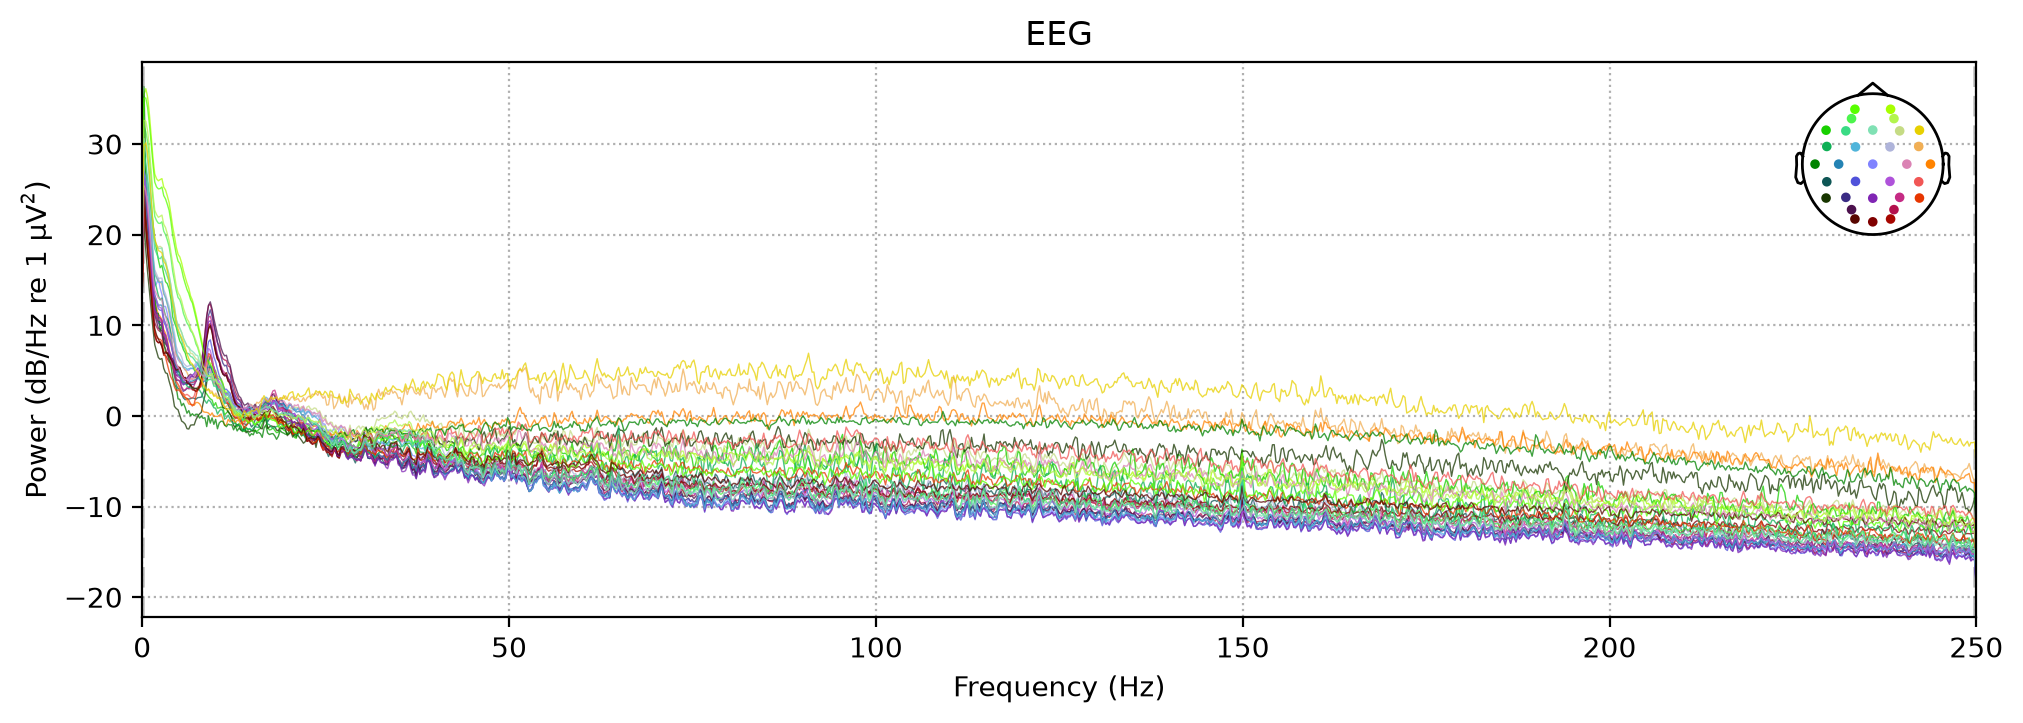

Channels marked as bad:
none
Channels marked as bad:
none
Channels marked as bad:
none


In [8]:
%matplotlib qt
# Switching to the interactive Qt backend here, right before the first plot — this stays in effect
# for the rest of the notebook, so it only needs to be set once.

raw.compute_psd().plot()

The PSD should look clean, displaying:
- The expected **EEG shoulder**,  a noticeable increase in power is observed around 4–10 Hz, reflecting theta and alpha activity.
- A general **1/f shape**, where power decreases with increasing frequency.
- Evidence of notch filters applied at specific frequencies (e.g., 50 Hz and harmonics), as power line noise artifacts are no longer visible.

In [10]:
# Apply notch filter at the power-line frequency and harmonics for the configured region
notch_freqs = config['power_line']['frequencies_by_region'][config['power_line']['region']]
raw.notch_filter(notch_freqs)
logger.info(f"Applied notch filter at {notch_freqs} Hz (region={config['power_line']['region']})")

Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 3301 samples (6.602 s)



INFO - Applied notch filter at [50, 100, 150] Hz (region=EU)


In [11]:
fig_psd = raw.compute_psd().plot()
save_fig(fig_psd, 'psd')

Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).


INFO - Saved figure 'psd' to figures/p34_psd.png


[PosixPath('figures/p34_psd.png')]

## (d) Inspecting raw data

The first step in cleaning the data is to visually inspect the recording and mark bad channels. This can involve reviewing notes taken during the recording session to identify bad electrode channels or directly examining the raw data for irregularities.

Steps for inspection:
1. **Plot the raw time series** using `raw.plot()` to visually check for channels with excessive noise or artifacts, and mark bad channels (see below).
2. **Inspect the power spectrum density (PSD)** to evaluate the frequency content of the signal and identify noise or unexpected patterns.

**How to decide if a channel is "bad"** — this is a judgment call, and the criterion matters more than it might seem:
- **Mark the channel bad** (then interpolate — step (f) below) if it is **consistently** noisy throughout the recording.
- A channel that is otherwise clean but has an isolated **jump** at one point in time does **not** need to be removed — that's a localized event, not a channel-level problem.
- If a channel is noisy **only in a handful of trials**, don't mark the whole channel bad — instead, **you can drop bad epochs** later (notebook 2).

For this participant, the raw data looks good overall, with no major issues. However, for practice purposes, **CP5** is marked as bad, as it shows minor jumping around second 360. Per the guidance above this is actually borderline — a single jump wouldn't normally warrant removal — but it demonstrates the process of identifying and handling bad channels.

These steps ensure the data is ready for further processing and cleaning.

In [12]:
# You can also screen through the raw data by plotting it.
# Show every channel the object contains (EEG + EOG + misc + stim), rather than a hardcoded count.
raw.plot(n_channels=len(raw.ch_names), duration=10, scalings=dict(eeg=100e-6))

# Note: You can already exclude some channels from the raw data if you see that they are noisy by clicking on the channel name in the plot
# They will then be stored in the raw.info['bads'] attribute

Using qt as 2D backend.


In [13]:
# Mark bad channels found during the visual inspection above (not config-driven - see note above)
raw.info['bads'] = ['CP5']
print(f"Bad channels: {raw.info['bads']}")
logger.info(f"Marked bad channels: {raw.info['bads']}")

INFO - Marked bad channels: ['CP5']


Bad channels: ['CP5']


## (e) Removing artifacts using Independent Component Analysis (ICA) and automatic component labeling

### Initializing the ICA instance

The parameters for initializing the ICA instance, read from `config['ica']`, are selected as follows:

- **`method='infomax'`**: Specifies the ICA algorithm to use. The Infomax method is chosen for its effectiveness in separating sources, particularly in EEG data. Additionally, this is combined with the extended Infomax approach, which improves the algorithm's ability to separate sub-Gaussian and super-Gaussian sources.
  
- **`fit_params=dict(extended=True)`**: Activates the extended Infomax feature, enhancing the method's capacity to handle diverse source distributions, such as those present in EEG data.

- **`random_state=97`**: Sets a fixed random seed for reproducibility. This ensures that the results of the ICA decomposition remain consistent across runs.

These parameters are a solid default for EEG data, and are a reasonable starting point — but they are not the only option (`picard` and `fastica` are common alternatives), so they're kept fully editable in `config['ica']`.

**Note**: channels already marked bad (step (d) above) are automatically excluded from the ICA fit — `ica.fit()` only uses "good" data channels by default, so make sure bad channels are marked *before* this step, not after.

### Preparing data for ICA

Before fitting the ICA, a **copy of the raw data** is created and high-pass/low-pass filtered between `config['ica']['filter_l_freq']` and `config['ica']['filter_h_freq']` Hz (1–100 Hz by default). This filtering range is selected to:

- Remove slow drifts and low-frequency noise, such as DC offsets, which can interfere with ICA's ability to separate independent components.
- Focus on the frequency range where most artifacts, such as eye blinks, muscle noise, and other physiological or environmental artifacts, are present.
- Improve ICA's ability to separate signal from noise while preserving relevant brain activity.

This range is an **advanced, editable** setting — the values above work well as a general default, but if you know your artifacts of interest live outside 1–100 Hz you can adjust `config['ica']['filter_l_freq']`/`['filter_h_freq']`.

This preparation step ensures that ICA operates on data optimized for identifying and removing artifacts while leaving the original raw data untouched for subsequent analyses.

In [14]:
# Initialize ICA instance
ica = mne.preprocessing.ICA(
    method=config['ica']['method'],  # picard, fastica
    fit_params=dict(extended=config['ica']['extended']),
    random_state=config['ica']['random_state'],
)

# Create a copy of the raw data to work with ICA, high-pass/low-pass filtered as configured. This is to enhance the detection of artifacts.
raw_ica = raw.copy().filter(l_freq=config['ica']['filter_l_freq'], h_freq=config['ica']['filter_h_freq'])

logger.info(f"Fitting ICA (method={config['ica']['method']}, filter={config['ica']['filter_l_freq']}-{config['ica']['filter_h_freq']} Hz)")

# Fit ICA (takes a few minutes to run)
ica.fit(raw_ica)

logger.info(f"ICA fit complete: {ica.n_components_} components")

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 1651 samples (3.302 s)



INFO - Fitting ICA (method=infomax, filter=1-100 Hz)


Fitting ICA to data using 31 channels (please be patient, this may take a while)
Selecting by non-zero PCA components: 31 components
Computing Extended Infomax ICA
Fitting ICA took 40.9s.


INFO - ICA fit complete: 31 components


### Visually inspect ICA components

ICA returns as many components as there are **good** channels it was fitted on — so with 32 EEG channels and `CP5` marked bad in step (d), this run produces **31** components, not 32. If you mark a different number of bad channels, that count changes accordingly.

In MNE, you can both plot the components (scalp topographies) and their sources (time series).

In [15]:
# Inspect ICA components.
# With many components MNE returns a list of figures (paged 20 at a time), which save_fig handles.
fig_components = ica.plot_components()
save_fig(fig_components, 'ica_components')

INFO - Saved figure 'ica_components' to figures/p34_ica_components_1.png, figures/p34_ica_components_2.png


[PosixPath('figures/p34_ica_components_1.png'),
 PosixPath('figures/p34_ica_components_2.png')]

In [16]:
# Inspect ICA sources
ica.plot_sources(raw_ica)

Creating RawArray with float64 data, n_channels=33, n_times=789500
    Range : 1180000 ... 1969499 =   2360.000 ...  3938.998 secs
Ready.


### Automatically detecting artifact components

Rather than deciding by eye which components are artifacts, MNE can flag them automatically. Two complementary detectors are used here, each targeting a different artifact type:

- **Eye blinks / eye movements** — `ica.find_bads_eog()` correlates every component's time course against the actual **EOG electrodes** (`config['channels']['eog']`). Because it compares against a real recorded signal, this is the most trustworthy of the automatic methods.
- **Muscle activity** — `ica.find_bads_muscle()` doesn't need a dedicated channel. It scores each component on its **power spectrum slope** (muscle activity is broadband and dominates high frequencies, unlike the 1/f falloff of genuine brain signal) combined with how **spatially focal** the component's topography is.

**Both detectors are threshold-driven, and both thresholds live in `config['ica']`.** For each one, **higher = stricter = fewer components flagged**:
- `eog_threshold` (default **3.0**) is a z-score on the correlation with the EOG channels.
- `muscle_threshold` (default **0.5**) scores each component against a typical muscle profile. MNE's default is fairly permissive on 32-channel EEG — if too many components are being flagged as muscle, raise this toward 0.8–1.0.

Everything flagged by either detector ends up in `ica.exclude`, so these two numbers directly control how much gets removed *and* how many inspection plots get generated further down. Check the printed count below before moving on.

**What about heart-beat artifacts?** MNE's equivalent function, `find_bads_ecg()`, needs a real **ECG channel** to correlate against. It can synthesize one from MEG sensors, but *not* from EEG — this recording has 32 EEG + 2 EOG + 2 mastoid + 1 stim channel and no ECG, so cardiac components cannot be detected this way. In practice this matters less for scalp EEG than for MEG: the cardiac field is far weaker at EEG electrodes, and blinks and muscle dominate the artifact budget. If your own setup does record ECG, you can add `ica.find_bads_ecg(raw_ica, ch_name='<your ECG channel>')` alongside the two detectors below.

As an **independent point of comparison**, the notebook also runs `mne_icalabel`, a neural network that classifies each component from its topography and spectrum alone ('brain', 'eye blink', 'muscle artifact', 'heart beat', ...). Its labels are only *printed* for you to compare against — they do not drive the exclusion decision.

In [17]:
# Detect blink events directly in the raw data, using the EOG channel(s) named in config.json.
# Note: this does NOT select ICA components - it finds when blinks happened, which is a useful
# sanity check that blinks are present and detectable before trusting any automatic component labelling.
eog_events = mne.preprocessing.find_eog_events(raw, ch_name=config['channels']['eog'])
logger.info(f"Detected {len(eog_events)} EOG (blink) events")

# Cut epochs around each detected blink and average them. A clean blink-evoked average with a
# clear deflection confirms the EOG channels are working and the blinks are well time-locked.
# The baseline (-0.5 to -0.2 s) is deliberately well before the blink onset: a window like
# (-0.2, 0) risks already containing the start of the eye movement.
eog_epochs = mne.preprocessing.create_eog_epochs(
    raw,
    ch_name=config['channels']['eog'],
    baseline=(-0.5, -0.2),
)
eog_evoked = eog_epochs.average()
logger.info(f"Created {len(eog_epochs)} blink epochs")

fig_eog = eog_evoked.plot(show=True)
save_fig(fig_eog, 'eog_evoked')

Using EOG channels: EXG1, EXG2
EOG channel index for this subject is: [32 33]
Filtering the data to remove DC offset to help distinguish blinks from saccades
Selecting channel EXG1 for blink detection
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5000 samples (10.000 s)

Now detecting blinks and generating corresponding events
Found 1371 significant peaks
Number of EOG events detected: 1371


INFO - Detected 1371 EOG (blink) events


Using EOG channels: EXG1, EXG2
EOG channel index for this subject is: [32 33]
Filtering the data to remove DC offset to help distinguish blinks from saccades
Selecting channel EXG1 for blink detection
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5000 samples (10.000 s)

Now detecting blinks and generating corresponding events
Found 1371 significant peaks
Number of EOG events detected: 1371
Not setting metadata
1371 matching events found
Applying baseline correction (mode: mean)
Using data from preloaded Raw for 1371 events and 501 original time points ...
0 bad epochs dropped


INFO - Created 1371 blink epochs
INFO - Saved figure 'eog_evoked' to figures/p34_eog_evoked.png


[PosixPath('figures/p34_eog_evoked.png')]

### Flagging components for exclusion

With the blink signal confirmed above, the two detectors now run against the ICA decomposition. Each returns the indices of the components it flags, plus a per-component score you can inspect.

The union of both sets becomes `ica.exclude` — the components that will be subtracted from the data when `ica.apply()` runs. Nothing is removed until that step, so you can still inspect and adjust the list first.

In [18]:
# Eye components: correlate each component's time course against the EOG channel(s).
# threshold is a z-score - higher means stricter, so fewer components get flagged.
eog_inds, eog_scores = ica.find_bads_eog(
    raw_ica,
    ch_name=config['channels']['eog'],
    threshold=config['ica']['eog_threshold'],
)

# Muscle components: score each component on spectrum slope + topography focality (no extra channel needed).
# Also higher = stricter. Both index lists come back sorted by score, strongest first.
muscle_inds, muscle_scores = ica.find_bads_muscle(
    raw_ica,
    threshold=config['ica']['muscle_threshold'],
)

print(f"Eye (EOG-correlated) components  [threshold={config['ica']['eog_threshold']}]:", eog_inds)
print(f"Muscle components                [threshold={config['ica']['muscle_threshold']}]:", muscle_inds)

# Components to remove: everything either detector flagged
ica.exclude = sorted(set(eog_inds) | set(muscle_inds))
print(f"\n{len(ica.exclude)} of {ica.n_components_} components marked for exclusion:", ica.exclude)
print("If that looks like too many, raise the thresholds in the 'ica' section of config.json.")

logger.info(f"find_bads_eog flagged (threshold={config['ica']['eog_threshold']}): {eog_inds}")
logger.info(f"find_bads_muscle flagged (threshold={config['ica']['muscle_threshold']}): {muscle_inds}")
logger.info(f"Components marked for exclusion ({len(ica.exclude)}/{ica.n_components_}): {ica.exclude}")

Using EOG channels: EXG1, EXG2
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5000 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.2

INFO - find_bads_eog flagged (threshold=3.0): [np.int64(0), np.int64(1)]
INFO - find_bads_muscle flagged (threshold=0.5): [1, 2, 3, 7, 8, 10, 11, 13, 14, 16, 20, 22, 24]
INFO - Components marked for exclusion (14/31): [np.int64(0), np.int64(1), 2, 3, 7, 8, 10, 11, 13, 14, 16, 20, 22, 24]


Eye (EOG-correlated) components  [threshold=3.0]: [np.int64(0), np.int64(1)]
Muscle components                [threshold=0.5]: [1, 2, 3, 7, 8, 10, 11, 13, 14, 16, 20, 22, 24]

14 of 31 components marked for exclusion: [np.int64(0), np.int64(1), 2, 3, 7, 8, 10, 11, 13, 14, 16, 20, 22, 24]
If that looks like too many, raise the thresholds in the 'ica' section of config.json.


In [19]:
# Independent comparison only - iclabel does NOT drive the exclusion decision above.
# It classifies each component from its topography and spectrum alone, so agreement with the
# EOG-correlation and muscle detectors is reassuring, and disagreement is worth a closer look.
ica_labels = label_components(raw_ica, ica, method='iclabel')
labels = ica_labels['labels']

print(f"{'comp':>5}  {'iclabel says':<18}  flagged by")
print('-' * 50)
for comp in range(ica.n_components_):
    flagged_by = []
    if comp in eog_inds:
        flagged_by.append('find_bads_eog')
    if comp in muscle_inds:
        flagged_by.append('find_bads_muscle')
    # Show every excluded component, plus any component iclabel considers non-brain
    if flagged_by or labels[comp] != 'brain':
        print(f"{comp:>5}  {labels[comp]:<18}  {', '.join(flagged_by) or '-'}")

logger.info(f"iclabel labels (info only): {dict(enumerate(labels))}")

INFO - iclabel labels (info only): {0: 'eye blink', 1: 'eye blink', 2: 'eye blink', 3: 'muscle artifact', 4: 'brain', 5: 'heart beat', 6: 'brain', 7: 'muscle artifact', 8: 'brain', 9: 'channel noise', 10: 'muscle artifact', 11: 'muscle artifact', 12: 'brain', 13: 'muscle artifact', 14: 'other', 15: 'brain', 16: 'muscle artifact', 17: 'brain', 18: 'brain', 19: 'brain', 20: 'muscle artifact', 21: 'brain', 22: 'brain', 23: 'brain', 24: 'eye blink', 25: 'brain', 26: 'brain', 27: 'brain', 28: 'brain', 29: 'brain', 30: 'brain'}


 comp  iclabel says        flagged by
--------------------------------------------------
    0  eye blink           find_bads_eog
    1  eye blink           find_bads_eog, find_bads_muscle
    2  eye blink           find_bads_eog, find_bads_muscle
    3  muscle artifact     find_bads_muscle
    5  heart beat          -
    7  muscle artifact     find_bads_muscle
    8  brain               find_bads_muscle
    9  channel noise       -
   10  muscle artifact     find_bads_muscle
   11  muscle artifact     find_bads_muscle
   13  muscle artifact     find_bads_muscle
   14  other               find_bads_muscle
   16  muscle artifact     find_bads_muscle
   20  muscle artifact     find_bads_muscle
   22  brain               find_bads_muscle
   24  eye blink           find_bads_eog, find_bads_muscle


In [20]:
# Apply cleaning to initial raw instance
ica.apply(raw)
logger.info("ICA applied to raw data")

Applying ICA to Raw instance
    Transforming to ICA space (31 components)
    Zeroing out 14 ICA components
    Projecting back using 31 PCA components


INFO - ICA applied to raw data


### Closer look at the flagged components

`plot_components` shows only a topography, and `plot_sources` only a raw time series — neither is enough on its own to *justify* excluding a component. `plot_properties` gives a fuller per-component view (time course, power spectrum, topography, and an epochs-image of the component activity) for each excluded component, so you can confirm why it looked like a blink or muscle artifact rather than just trusting the automatic detectors.

A genuine **blink** component typically shows a frontal topography, large slow deflections in the time course, and power concentrated at low frequencies. A **muscle** component typically shows a focal topography near the edge of the montage (temporalis, neck) and a spectrum that stays high or rises toward the upper frequencies instead of falling off as 1/f.

These plots are drawn from `raw_ica`, the unmodified copy the ICA was fitted on, so they show the components as they were regardless of when `ica.apply()` runs. If a component here looks like genuine brain activity, adjust `ica.exclude` and re-run `ica.apply()` on a fresh copy of the raw data.

In [21]:
logger.info(f"Inspecting properties of excluded components: {ica.exclude}")

for comp in ica.exclude:
    # plot_properties returns a list (one figure per picked component)
    figs = ica.plot_properties(raw_ica, picks=comp)
    save_fig(figs, f'ica_properties_comp{comp}')

INFO - Inspecting properties of excluded components: [np.int64(0), np.int64(1), 2, 3, 7, 8, 10, 11, 13, 14, 16, 20, 22, 24]


    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
789 matching events found
No baseline correction applied
0 projection items activated


INFO - Saved figure 'ica_properties_comp0' to figures/p34_ica_properties_comp0.png


    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
789 matching events found
No baseline correction applied
0 projection items activated


INFO - Saved figure 'ica_properties_comp1' to figures/p34_ica_properties_comp1.png


...

INFO - Saved figure 'ica_properties_comp20' to figures/p34_ica_properties_comp20.png


    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
789 matching events found
No baseline correction applied
0 projection items activated


INFO - Saved figure 'ica_properties_comp22' to figures/p34_ica_properties_comp22.png


    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
789 matching events found
No baseline correction applied
0 projection items activated


INFO - Saved figure 'ica_properties_comp24' to figures/p34_ica_properties_comp24.png


## (f) Interpolating bad channels

Now, the raw instance is cleaned from artifacts. The data is clean now, so in a last step, the bad channels can be interpolated.

`interpolate_bads()` reconstructs each bad channel as a weighted combination of its neighbors, using the sensor positions from the montage set in step (a) — this is why getting the montage right matters even for channels you never mark bad. It also prints the fitted head radius/origin it used for the spline interpolation. This estimate depends on head size: EEG caps commonly come in standard sizes (S/M/L or by head circumference), and using the wrong cap size for a participant subtly worsens interpolation and source localization. Some labs go further and digitize each participant's actual 3D head shape (e.g. with a Polhemus digitizer) for more accurate electrode positions — that's an advanced/optional step this tutorial doesn't cover, but worth knowing about if interpolation quality matters a lot for your analysis.

Before interpolating, it's worth visually confirming where the bad channel(s) actually sit relative to the rest of the montage — `plot_sensors` highlights any channel currently in `raw.info['bads']` in red.

In [22]:
# 2D sensor layout, bad channels shown in red (use kind='3d' instead if you have pyvista installed)
fig_sensors = raw.plot_sensors(kind='topomap', show_names=True)
save_fig(fig_sensors, 'sensors')

INFO - Saved figure 'sensors' to figures/p34_sensors.png


[PosixPath('figures/p34_sensors.png')]

In [23]:
logger.info(f"Interpolating bad channels: {raw.info['bads']}")
raw.interpolate_bads(reset_bads=True)
logger.info("Interpolation complete")

INFO - Interpolating bad channels: ['CP5']


Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.0 mm
Computing interpolation matrix from 31 sensor positions
Interpolating 1 sensors


INFO - Interpolation complete


In [24]:
# Optional: if you browse the data now, you can see that it is cleaned
raw.plot(n_channels=len(raw.ch_names), duration=10, scalings=dict(eeg=100e-6))

## (g) Filtering the data in auditory-relevant frequencies

In this step, the data is filtered to the band given by `config['filter_bands']`, which for this study's auditory speech-processing analysis is 0.5–30 Hz.

**Which band is "correct" depends on the analysis, not just the dataset.** Rather than hardcoding one band, `config['filter_bands']` stores a **dictionary of named options** (`auditory_erp`, `broadband`, `alpha`, ...) plus an `active` key selecting which one this run uses — add your own named band and point `active` at it instead of editing numbers inline.

**Why the high-pass edge matters**: sweat and other slow-drift artifacts typically only distort the signal over a timescale of 3+ seconds, so they show up as very low-frequency drift. Increasing the high-pass cutoff removes this kind of drift, but it also increasingly distorts genuine slow components of the ERP. As a rule of thumb, keep the high-pass edge at **0.5 Hz or below** unless you have a specific, understood reason to go higher.

In [25]:
# Final filter using the active band selected in config.json
l_freq, h_freq = config['filter_bands']['options'][config['filter_bands']['active']]
raw.filter(l_freq, h_freq)
logger.info(f"Applied final filter: {l_freq}-{h_freq} Hz (band='{config['filter_bands']['active']}')")

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 3301 samples (6.602 s)



INFO - Applied final filter: 0.5-30 Hz (band='auditory_erp')


In [26]:
# Final inspection before saving
raw.plot(n_channels=len(raw.ch_names), duration=10, scalings=dict(eeg=100e-6))

## (h) Caching cleaned data for further analyses

In this final step, the cleaned raw data is cached in MNE’s native .fif format to a folder created at the beginning of this script. This file will be loaded in the next notebook for further processing.

In [27]:
# Save the cleaned raw data
save_path = cleaned_data_folder / f"{participant_stem}_cleaned_raw.fif"
raw.save(save_path, overwrite=True)
logger.info(f"Saved cleaned data to {save_path}")

Overwriting existing file.
Writing /Users/bsertc/Desktop/NeuroPipe/cleaned_data/p34_cleaned_raw.fif
Overwriting existing file.
Closing /Users/bsertc/Desktop/NeuroPipe/cleaned_data/p34_cleaned_raw.fif
[done]


INFO - Saved cleaned data to cleaned_data/p34_cleaned_raw.fif


## (i) Generating a cleaning report

As a final step, `mne.Report` bundles the key QC outputs from this run — the cleaned raw data with its PSD, and the ICA decomposition together with which components were excluded — into a single, self-contained HTML file. This is saved to `config['paths']['reports_folder']` and can be opened in any browser or shared with a collaborator without needing to re-run the notebook, which is a nicer artifact to keep per participant than a folder of loose screenshots.

In [30]:
reports_folder = Path(config['paths']['reports_folder'])
reports_folder.mkdir(exist_ok=True)

report = mne.Report(title=f"EEG cleaning report — {participant_filename}")
report.add_raw(raw=raw, title='Cleaned raw data', psd=True, butterfly=False)
report.add_ica(ica=ica, title='ICA', inst=raw_ica, picks=ica.exclude)

report_path = reports_folder / f"{participant_stem}_cleaning_report.html"
report.save(report_path, overwrite=True)

logger.info(f"Saved cleaning report to {report_path}")

Embedding : jquery-3.6.0.min.js
Embedding : bootstrap.bundle.min.js
Embedding : bootstrap.min.css
Embedding : bootstrap-table/bootstrap-table.min.js
Embedding : bootstrap-table/bootstrap-table.min.css
Embedding : bootstrap-table/bootstrap-table-copy-rows.min.js
Embedding : bootstrap-table/bootstrap-table-export.min.js
Embedding : bootstrap-table/tableExport.min.js
Embedding : bootstrap-icons/bootstrap-icons.mne.min.css
Embedding : highlightjs/highlight.min.js
Embedding : highlightjs/atom-one-dark-reasonable.min.css
Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).
Applying ICA to Raw instance
    Transforming to ICA space (31 components)
    Zeroing out 14 ICA components
    Projecting back using 31 PCA components
    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
789 matching events found
No baseline correction applied
0 projection items activated
    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata

INFO - Saved cleaning report to reports/p34_cleaning_report.html
